# 02 - Feature Engineering (Enhanced)

**New features added:**
- Tempo & Efficiency (possessions, points per 100 poss)
- Complete Defensive Four Factors
- Recent Form (last 10 games)
- Momentum indicators
- Expanded Massey systems (SAG, RPI)
- Matchup interaction features
- Historical seed upset priors

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Import enhanced feature functions
from src.features import (
    build_team_features,
    build_matchup_df,
    build_all,
)

DATA_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
OUT_DIR = Path('../outputs')

## 1. Build Enhanced Per-Team Season Features

In [2]:
# Build features for both genders
team_feats = build_all(genders=("M", "W"))

m_feats = team_feats["M"]
w_feats = team_feats["W"]

print(f"\nMen's features: {m_feats.shape}")
print(f"Women's features: {w_feats.shape}")

[M] Computing offensive Four Factors...
[M] Computing defensive Four Factors...
[M] Computing tempo and efficiency...
[M] Loading seed data...
[M] Merging all features...
[M] Saved to /Users/adamgold/Desktop/MM_26/data/processed/M_team_features.csv
[M] Shape: (8346, 50)
[M] Columns: ['Season', 'TeamID', 'Games', 'Wins', 'PointsFor', 'PointsAgn', 'WinPct', 'ASTpg', 'TOpg', 'STLpg', 'BLKpg', 'ORpg', 'DRpg', 'PFpg', 'PointDiff', 'FGpct', 'FG3pct', 'FTpct', 'FG3Rate', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'FTR', 'Opp_eFG_pct', 'Opp_TOV_pct', 'DRB_pct', 'Opp_FTR', 'Tempo', 'OffEff', 'DefEff', 'NetEff', 'Recent_WinPct', 'Recent_PointDiff', 'Recent_Games', 'Recent_Tempo', 'Recent_OffEff', 'Recent_DefEff', 'Recent_NetEff', 'rank_MAS', 'rank_MOR', 'rank_POM', 'rank_RPI', 'rank_SAG', 'rank_composite', 'rank_std', 'SeedNum', 'Region', 'MadeTourney', 'Momentum_WinPct', 'Momentum_NetEff']
[W] Computing offensive Four Factors...
[W] Computing defensive Four Factors...
[W] Computing tempo and efficiency..

In [3]:
# Display all columns - should show new features
print("Men's feature columns:")
print(list(m_feats.columns))

Men's feature columns:
['Season', 'TeamID', 'Games', 'Wins', 'PointsFor', 'PointsAgn', 'WinPct', 'ASTpg', 'TOpg', 'STLpg', 'BLKpg', 'ORpg', 'DRpg', 'PFpg', 'PointDiff', 'FGpct', 'FG3pct', 'FTpct', 'FG3Rate', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'FTR', 'Opp_eFG_pct', 'Opp_TOV_pct', 'DRB_pct', 'Opp_FTR', 'Tempo', 'OffEff', 'DefEff', 'NetEff', 'Recent_WinPct', 'Recent_PointDiff', 'Recent_Games', 'Recent_Tempo', 'Recent_OffEff', 'Recent_DefEff', 'Recent_NetEff', 'rank_MAS', 'rank_MOR', 'rank_POM', 'rank_RPI', 'rank_SAG', 'rank_composite', 'rank_std', 'SeedNum', 'Region', 'MadeTourney', 'Momentum_WinPct', 'Momentum_NetEff']


In [4]:
# Check data types and missingness
print("\n=== Men's Data Summary ===")
print(f"Shape: {m_feats.shape}")
print(f"\nData types:")
print(m_feats.dtypes)

print(f"\nMissing values:")
miss = m_feats.isnull().mean().sort_values(ascending=False)
print(miss[miss > 0])


=== Men's Data Summary ===
Shape: (8346, 50)

Data types:
Season                int64
TeamID                int64
Games                 int64
Wins                  int64
PointsFor           float64
PointsAgn           float64
WinPct              float64
ASTpg               float64
TOpg                float64
STLpg               float64
BLKpg               float64
ORpg                float64
DRpg                float64
PFpg                float64
PointDiff           float64
FGpct               float64
FG3pct              float64
FTpct               float64
FG3Rate             float64
eFG_pct             float64
TOV_pct             float64
ORB_pct             float64
FTR                 float64
Opp_eFG_pct         float64
Opp_TOV_pct         float64
DRB_pct             float64
Opp_FTR             float64
Tempo               float64
OffEff              float64
DefEff              float64
NetEff              float64
Recent_WinPct       float64
Recent_PointDiff    float64
Recent_Games     

In [5]:
# Display sample of tournament teams
m_tourney = m_feats[m_feats['MadeTourney'] == 1].copy()
print(f"Tournament teams in dataset: {len(m_tourney)}")
m_tourney.head()

Tournament teams in dataset: 1472


,Season,TeamID,Games,Wins,PointsFor,PointsAgn,WinPct,ASTpg,TOpg,STLpg,...,rank_POM,rank_RPI,rank_SAG,rank_composite,rank_std,SeedNum,Region,MadeTourney,Momentum_WinPct,Momentum_NetEff
2,2003,1104,28,17,69.285714,65.000000,0.607143,12.107143,13.285714,6.607143,...,33.0,38.0,37.0,35.0,5.787918,10,Y,1,-0.207143,-4.804771
9,2003,1112,28,25,85.214286,70.250000,0.892857,17.642857,14.785714,8.464286,...,3.0,2.0,2.0,2.8,0.836660,1,Z,1,0.007143,-2.785464
10,2003,1113,29,18,75.965517,69.172414,0.620690,15.551724,14.000000,5.206897,...,32.0,32.0,32.0,31.6,6.387488,10,Z,1,-0.020690,-0.704624
16,2003,1120,30,19,70.100000,65.566667,0.633333,13.400000,15.900000,8.033333,...,45.0,36.0,43.0,42.6,3.781534,10,W,1,-0.233333,-18.047419
17,2003,1122,27,20,69.703704,67.703704,0.740741,13.407407,15.222222,7.037037,...,123.0,73.0,103.0,104.4,33.746111,13,W,1,0.159259,6.698332


## 2. Feature Distributions (Tournament Teams)

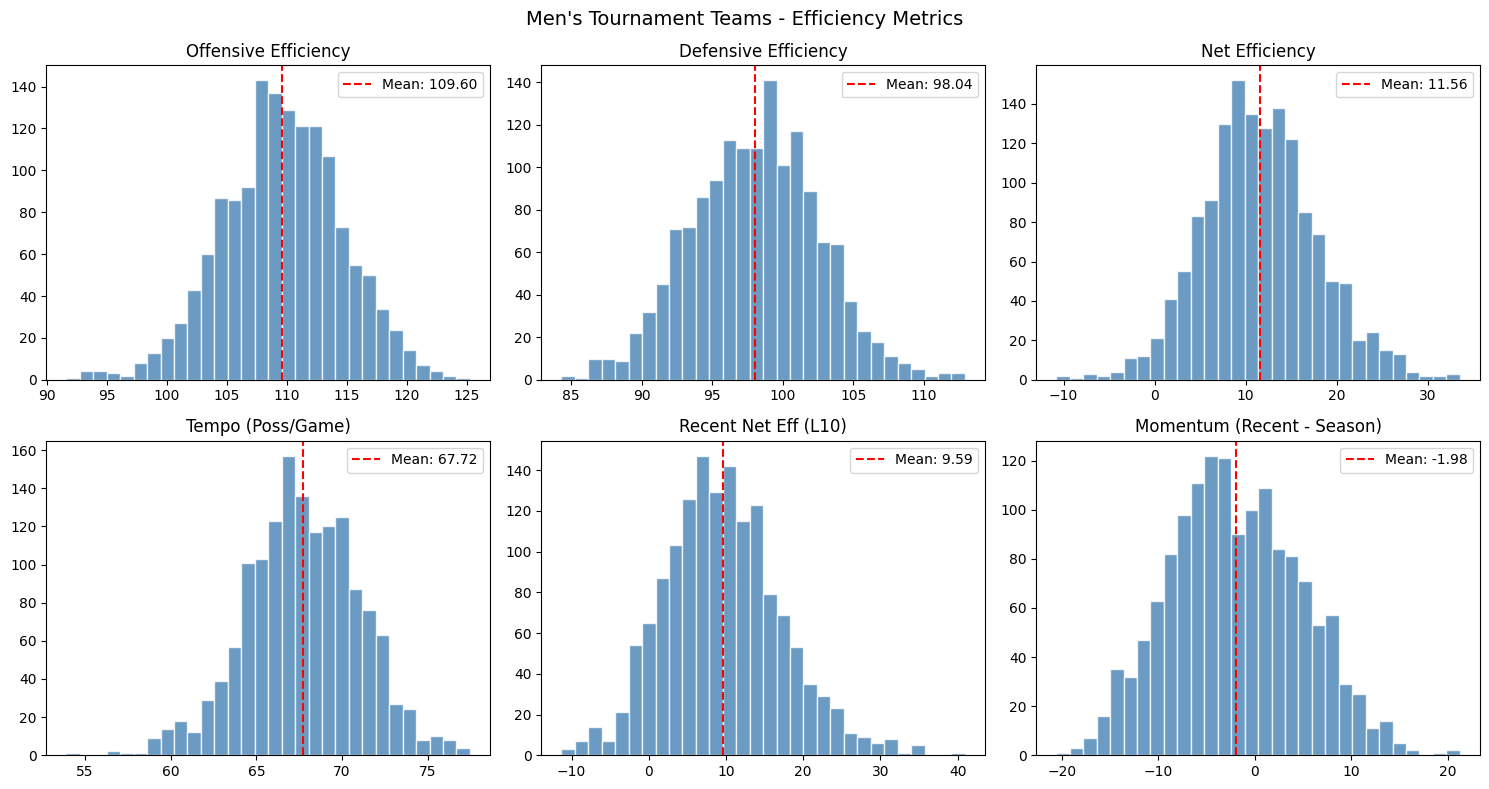

In [6]:
# Key efficiency metrics distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Men's Tournament Teams - Efficiency Metrics", fontsize=14)

plot_cols = ['OffEff', 'DefEff', 'NetEff', 'Tempo', 'Recent_NetEff', 'Momentum_NetEff']
titles = ['Offensive Efficiency', 'Defensive Efficiency', 'Net Efficiency',
          'Tempo (Poss/Game)', 'Recent Net Eff (L10)', 'Momentum (Recent - Season)']

for ax, col, title in zip(axes.flat, plot_cols, titles):
    if col in m_tourney.columns:
        data = m_tourney[col].dropna()
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
        ax.set_title(title)
        ax.legend()
    else:
        ax.text(0.5, 0.5, f'{col}\nNot Available', ha='center', va='center')
        ax.set_title(title)

plt.tight_layout()
# plt.savefig(OUT_DIR / 'efficiency_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

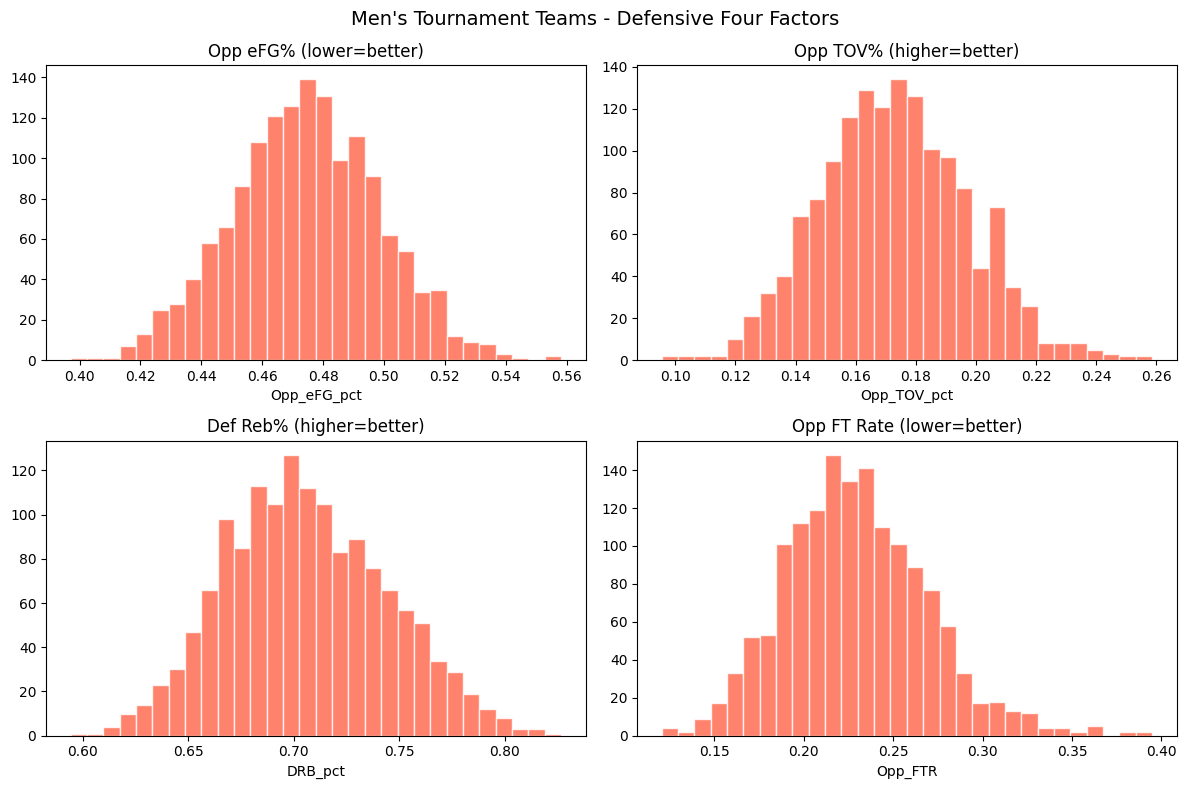

In [7]:
# Defensive Four Factors distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Men's Tournament Teams - Defensive Four Factors", fontsize=14)

def_cols = ['Opp_eFG_pct', 'Opp_TOV_pct', 'DRB_pct', 'Opp_FTR']
def_titles = ['Opp eFG% (lower=better)', 'Opp TOV% (higher=better)',
              'Def Reb% (higher=better)', 'Opp FT Rate (lower=better)']

for ax, col, title in zip(axes.flat, def_cols, def_titles):
    if col in m_tourney.columns:
        data = m_tourney[col].dropna()
        ax.hist(data, bins=30, color='tomato', edgecolor='white', alpha=0.8)
        ax.set_title(title)
        ax.set_xlabel(col)
    else:
        ax.text(0.5, 0.5, f'{col}\nNot Available', ha='center', va='center')

plt.tight_layout()
# plt.savefig(OUT_DIR / 'defensive_4f_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Build Matchup-Level Training Dataset

In [8]:
# Build matchup dataframes with new features
m_train, m_feature_cols = build_matchup_df(m_feats, gender="M", mode="train",
                                            include_interactions=True)
w_train, w_feature_cols = build_matchup_df(w_feats, gender="W", mode="train",
                                            include_interactions=True)

print(f"\nMen's training matchups: {m_train.shape}")
print(f"Women's training matchups: {w_train.shape}")
print(f"\nLabel distribution (men):")
print(m_train['Label'].value_counts())


[M] Building matchup DataFrame (mode=train)...
[M] Matchup shape: (1449, 147)
[M] Feature breakdown:
         Diff features: 45
         Ratio features: 5
         Interaction features: 3
         Total: 53

[W] Building matchup DataFrame (mode=train)...
[W] Matchup shape: (961, 129)
[W] Feature breakdown:
         Diff features: 39
         Ratio features: 5
         Interaction features: 3
         Total: 47

Men's training matchups: (1449, 147)
Women's training matchups: (961, 129)

Label distribution (men):
Label
1    725
0    724
Name: count, dtype: int64


In [9]:
# Display all feature columns
print(f"Total features: {len(m_feature_cols)}")
print(f"\nFeature breakdown:")

diff_cols = [c for c in m_feature_cols if c.startswith('diff_')]
ratio_cols = [c for c in m_feature_cols if c.startswith('ratio_')]
interact_cols = [c for c in m_feature_cols if c.startswith('interact_') or c in ['SeedDiff', 'SeedPrior']]

print(f"  Diff features ({len(diff_cols)}): {diff_cols[:5]}...")
print(f"  Ratio features ({len(ratio_cols)}): {ratio_cols}")
print(f"  Interaction features ({len(interact_cols)}): {interact_cols}")

Total features: 53

Feature breakdown:
  Diff features (45): ['diff_Games', 'diff_Wins', 'diff_PointsFor', 'diff_PointsAgn', 'diff_WinPct']...
  Ratio features (5): ['ratio_OffEff', 'ratio_DefEff', 'ratio_Tempo', 'ratio_eFG_pct', 'ratio_WinPct']
  Interaction features (3): ['interact_tempo_eff', 'interact_physical', 'SeedDiff']


## 4. Feature Correlation with Outcome

In [10]:
# Compute correlation of each feature with Label
correlations = {}
for col in m_feature_cols:
    valid = m_train[[col, 'Label']].dropna()
    if len(valid) > 50:
        correlations[col] = valid[col].corr(valid['Label'])

corr_series = pd.Series(correlations).sort_values(key=abs, ascending=False)

print("Top 20 features by correlation with outcome:")
print(corr_series.head(20).to_string())

Top 20 features by correlation with outcome:
SeedDiff               -0.482353
diff_SeedNum           -0.482353
diff_rank_MOR          -0.455381
diff_rank_POM          -0.450900
diff_rank_SAG          -0.450779
diff_rank_RPI          -0.443629
diff_rank_MAS          -0.432449
diff_rank_std          -0.407578
diff_PointDiff          0.405514
diff_NetEff             0.404267
diff_Wins               0.371177
diff_OffEff             0.333609
ratio_OffEff            0.330770
diff_WinPct             0.325598
ratio_WinPct            0.318906
diff_Momentum_NetEff   -0.289147
ratio_DefEff           -0.241549
diff_DefEff            -0.241127
diff_Games              0.239721
diff_PointsFor          0.233230


/Users/adamgold/Desktop/MM_26/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/adamgold/Desktop/MM_26/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


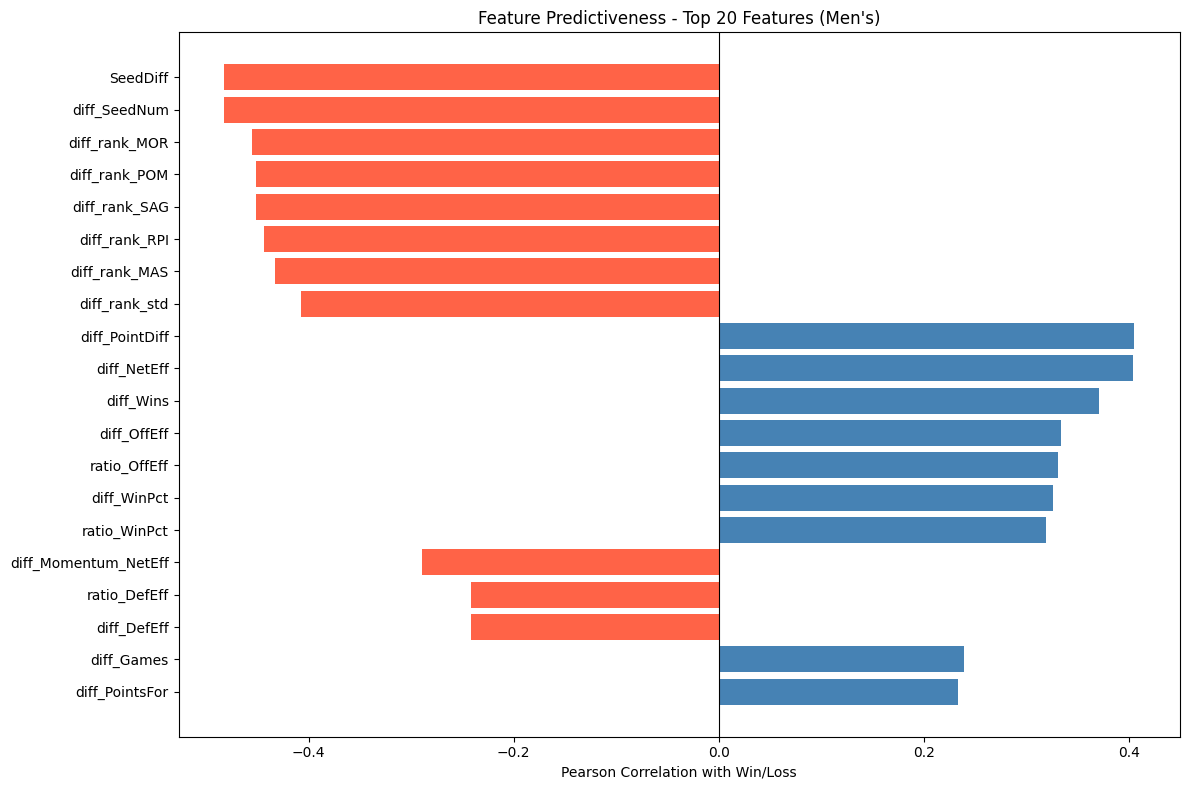

In [11]:
# Visualize top 20 correlations
top20 = corr_series.head(20)

plt.figure(figsize=(12, 8))
colors = ['steelblue' if v > 0 else 'tomato' for v in top20.values]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with Win/Loss')
plt.title("Feature Predictiveness - Top 20 Features (Men's)")
plt.tight_layout()
# plt.savefig(OUT_DIR / 'feature_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Save Training Datasets

In [12]:
# dropping column cuz of na's
# m_train = m_train.drop('A_rank_SAG', axis = 1)
# m_train = m_train.drop('B_rank_SAG', axis = 1)
# #w_train = w_train.drop('A_rank_SAG', axis = 1)
# #w_train = w_train.drop('B_rank_SAG', axis = 1)

# Save training matchup DataFrames
m_train.to_csv(PROC_DIR / 'M_matchup_train.csv', index=False)
w_train.to_csv(PROC_DIR / 'W_matchup_train.csv', index=False)

# Save feature column names
with open(PROC_DIR / 'M_feature_cols.json', 'w') as f:
    json.dump(m_feature_cols, f)
with open(PROC_DIR / 'W_feature_cols.json', 'w') as f:
    json.dump(w_feature_cols, f)

print("Saved:")
print(f"  data/processed/M_matchup_train.csv ({m_train.shape})")
print(f"  data/processed/W_matchup_train.csv ({w_train.shape})")
print(f"  data/processed/M_feature_cols.json ({len(m_feature_cols)} features)")
print(f"  data/processed/W_feature_cols.json ({len(w_feature_cols)} features)")

Saved:
  data/processed/M_matchup_train.csv ((1449, 147))
  data/processed/W_matchup_train.csv ((961, 129))
  data/processed/M_feature_cols.json (53 features)
  data/processed/W_feature_cols.json (47 features)


## 7. Build 2026 Prediction Datasets

In [13]:
# m_feats = m_train.drop(columns = ['diff_rank_SAG'])
# w_feats = m_train.drop(columns = ['diff_rank_SAG'])

# Build prediction matchups for 2026
m_pred, _ = build_matchup_df(m_feats, gender="M", mode="predict",
                              include_interactions=True)
w_pred, _ = build_matchup_df(w_feats, gender="W", mode="predict",
                              include_interactions=True)

# dropping sag diff column cuz of Nas
# m_pred.drop('diff_rank_SAG', axis = 1, inplace = True)

print(f"Men's 2026 prediction matchups: {m_pred.shape}")
print(f"Women's 2026 prediction matchups: {w_pred.shape}")

# Save prediction datasets
m_pred.to_csv(PROC_DIR / 'M_matchup_predict.csv', index=False)
w_pred.to_csv(PROC_DIR / 'W_matchup_predict.csv', index=False)
print("\nSaved prediction datasets.")


[M] Building matchup DataFrame (mode=predict)...
[M] Matchup shape: (66430, 148)
[M] Feature breakdown:
         Diff features: 45
         Ratio features: 5
         Interaction features: 3
         Total: 53

[W] Building matchup DataFrame (mode=predict)...
[W] Matchup shape: (65703, 130)
[W] Feature breakdown:
         Diff features: 39
         Ratio features: 5
         Interaction features: 3
         Total: 47
Men's 2026 prediction matchups: (66430, 148)
Women's 2026 prediction matchups: (65703, 130)

Saved prediction datasets.


In [14]:
# Check for missing features in prediction set
print("Missing features in 2026 men's prediction set:")
miss = m_pred[m_feature_cols].isnull().mean().sort_values(ascending=False)
print(miss[miss > 0].head(10) if (miss > 0).any() else "None - all features complete!")

Missing features in 2026 men's prediction set:
diff_rank_SAG    1.0
dtype: float64


# NEED TO DROP DIFF_RANK_SAG COLUMN IN NEXT FILE

## Summary

| Metric | Men's | Women's |
|--------|-------|----------|
| Team-season rows | | |
| Total features | | |
| Training matchups | | |
| 2026 prediction matchups | | |

**New features added:**
- Tempo & Efficiency (OffEff, DefEff, NetEff, Tempo)
- Defensive Four Factors (Opp_eFG%, Opp_TOV%, DRB%, Opp_FTR)
- Recent Form (last 10 games performance)
- Momentum (recent vs season average)
- Expanded Massey ordinals (SAG, RPI, rank_std)
- Interaction features (tempo*efficiency, seed prior)

**Next:** `03_model.ipynb` - train models with new features